# Region-Adaptive Super-Resolution for Urban Satellite Imagery

**Goal:** Take a low-resolution satellite patch (simulating Sentinel-2-like imagery) and upscale it 4×, spending compute **non-uniformly**: heavy attention-based reconstruction on semantically important regions (buildings, roads) and cheap convolutional passthrough elsewhere (farmland, forest, water).

A small learned **Region Importance Network (RIN)** decides per-pixel where "important" is. Training is guided not just by pixel fidelity, but also by whether a **frozen segmentation model** can correctly identify land-cover classes in the generated image — forcing the SR output to be useful for downstream urban analysis.

## Pipeline Overview
1. **Train RIN** (20 epochs) → freeze
2. **Train Segmenter** (30 epochs, ResNet-34 backbone) → freeze
3. **Train Baseline SR** (30 epochs, uniform attention, no task guidance)
4. **Train Adaptive SR** (50 epochs, RIN-guided + task-guided + perceptual loss)
5. **Evaluate & Compare** all methods

## Novelty Claims
- Adaptive per-region compute allocation via learned importance maps
- Task-guided training via frozen segmenter for downstream utility
- Hard-gated window routing at inference for actual compute savings

In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.models as models
import numpy as np, cv2, random, glob, time, gc, json
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import OrderedDict
from torch.amp import GradScaler, autocast  # mixed precision

# ==================== DEVICE ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ==================== CONSTANTS ====================
SCALE = 4
NUM_CLASSES = 8
IGNORE_INDEX = 0
HIGH_IMPORTANCE_CLASSES = {2, 3}  # building, road
HR_PATCH = 256
LR_PATCH = HR_PATCH // SCALE  # 64

# ==================== PATHS (Kaggle) ====================
LOVEDA_ROOT = '/kaggle/input/datasets/nvamsikrishna1/loveda-raw/loveda_zips'
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# ==================== HYPERPARAMETERS ====================
RIN_EPOCHS = 20
SEG_EPOCHS = 30
BASELINE_SR_EPOCHS = 30
ADAPTIVE_SR_EPOCHS = 50

BATCH_SIZE = 16        # reduced from 32 to save RAM
SR_BATCH_SIZE = 4      # reduced from 8 for T4 safety with AMP

LAMBDA_EDGE = 0.5
LAMBDA_SEG = 0.5
LAMBDA_PERCEPTUAL = 0.1
IMPORTANCE_WEIGHT = 3.0

# ==================== MEMORY SETTINGS ====================
NUM_WORKERS = 2         # fewer workers = less RAM per DataLoader
USE_AMP = True          # mixed precision halves GPU memory

print(f"AMP: {'enabled' if USE_AMP else 'disabled'}")
print(f"RAM usage: {os.popen('free -h').read()}" if os.path.exists('/proc/meminfo') else '')
print("Setup complete.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
AMP: enabled
RAM usage:                total        used        free      shared  buff/cache   available
Mem:            31Gi       1.1Gi        26Gi       1.0Mi       3.6Gi        29Gi
Swap:             0B          0B          0B

Setup complete.


## 2. Dataset — LoveDA

**LoveDA** (Land-cover Domain Adaptation dataset) with `Train` and `Val` splits, each containing `Urban` and `Rural` scenes.

| ID | Class | Importance |
|----|-------|------------|
| 0 | no-data / ignore | — |
| 1 | background | Low |
| 2 | **building** | **High** |
| 3 | **road** | **High** |
| 4 | water | Low |
| 5 | barren | Low |
| 6 | forest | Low |
| 7 | agriculture | Low |

**Degradation pipeline:** HR → Gaussian blur (σ=1.5) → bicubic downsample ×4 → Gaussian noise (std=2.0), simulating Sentinel-2-like imaging conditions.

In [2]:
# ==================== FILE LIST BUILDER ====================
def build_file_lists(root, split_folder='Train'):
    img_paths, mask_paths = [], []
    for scene in ['Urban', 'Rural']:
        img_dir = os.path.join(root, split_folder, split_folder, scene, 'images_png')
        mask_dir = os.path.join(root, split_folder, split_folder, scene, 'masks_png')
        if not os.path.isdir(img_dir):
            print(f"WARNING: not found -> {img_dir}"); continue
        imgs = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        for p in imgs:
            fname = os.path.basename(p)
            mp = os.path.join(mask_dir, fname)
            if os.path.exists(mp):
                img_paths.append(p); mask_paths.append(mp)
    return img_paths, mask_paths

train_imgs, train_masks = build_file_lists(LOVEDA_ROOT, 'Train')
val_imgs, val_masks = build_file_lists(LOVEDA_ROOT, 'Val')
print(f"Train pairs: {len(train_imgs)} | Val pairs: {len(val_imgs)}")

# ==================== DEGRADATION PIPELINE ====================
def degrade(hr_patch, scale=SCALE, blur_sigma=1.5, noise_std=2.0):
    """Simulate Sentinel-2-like degradation: blur -> downsample -> noise."""
    blurred = cv2.GaussianBlur(hr_patch, (0, 0), sigmaX=blur_sigma)
    h, w = hr_patch.shape[:2]
    lr = cv2.resize(blurred, (w // scale, h // scale), interpolation=cv2.INTER_CUBIC)
    noise = np.random.normal(0, noise_std, lr.shape)
    return np.clip(lr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# ==================== DATASET CLASS ====================
class LoveDASRDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=HR_PATCH, augment=True):
        self.image_paths, self.mask_paths = image_paths, mask_paths
        self.patch_size, self.augment = patch_size, augment

    def __len__(self):
        return len(self.image_paths)

    def _random_crop(self, img, mask):
        h, w = img.shape[:2]; ps = self.patch_size
        if h < ps or w < ps:
            pad_h, pad_w = max(0, ps - h), max(0, ps - w)
            img = cv2.copyMakeBorder(img, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
            h, w = img.shape[:2]
        top, left = random.randint(0, h - ps), random.randint(0, w - ps)
        return img[top:top+ps, left:left+ps], mask[top:top+ps, left:left+ps]

    def _augment(self, img, mask):
        if random.random() < 0.5:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() < 0.5:
            img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        k = random.choice([0, 1, 2, 3])
        if k:
            img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()
        return img, mask

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        hr, mask = self._random_crop(img, mask)
        if self.augment:
            hr, mask = self._augment(hr, mask)
        lr = degrade(hr)
        importance = np.isin(mask, list(HIGH_IMPORTANCE_CLASSES)).astype(np.float32)
        return {
            'lr': torch.from_numpy(lr).permute(2, 0, 1).float() / 255.0,
            'hr': torch.from_numpy(hr).permute(2, 0, 1).float() / 255.0,
            'mask': torch.from_numpy(mask.astype(np.int64)),
            'importance': torch.from_numpy(importance).unsqueeze(0)
        }

train_dataset = LoveDASRDataset(train_imgs, train_masks, augment=True)
val_dataset = LoveDASRDataset(val_imgs, val_masks, augment=False)
print(f"Train dataset: {len(train_dataset)} samples | Val dataset: {len(val_dataset)} samples")

Train pairs: 2522 | Val pairs: 1669
Train dataset: 2522 samples | Val dataset: 1669 samples


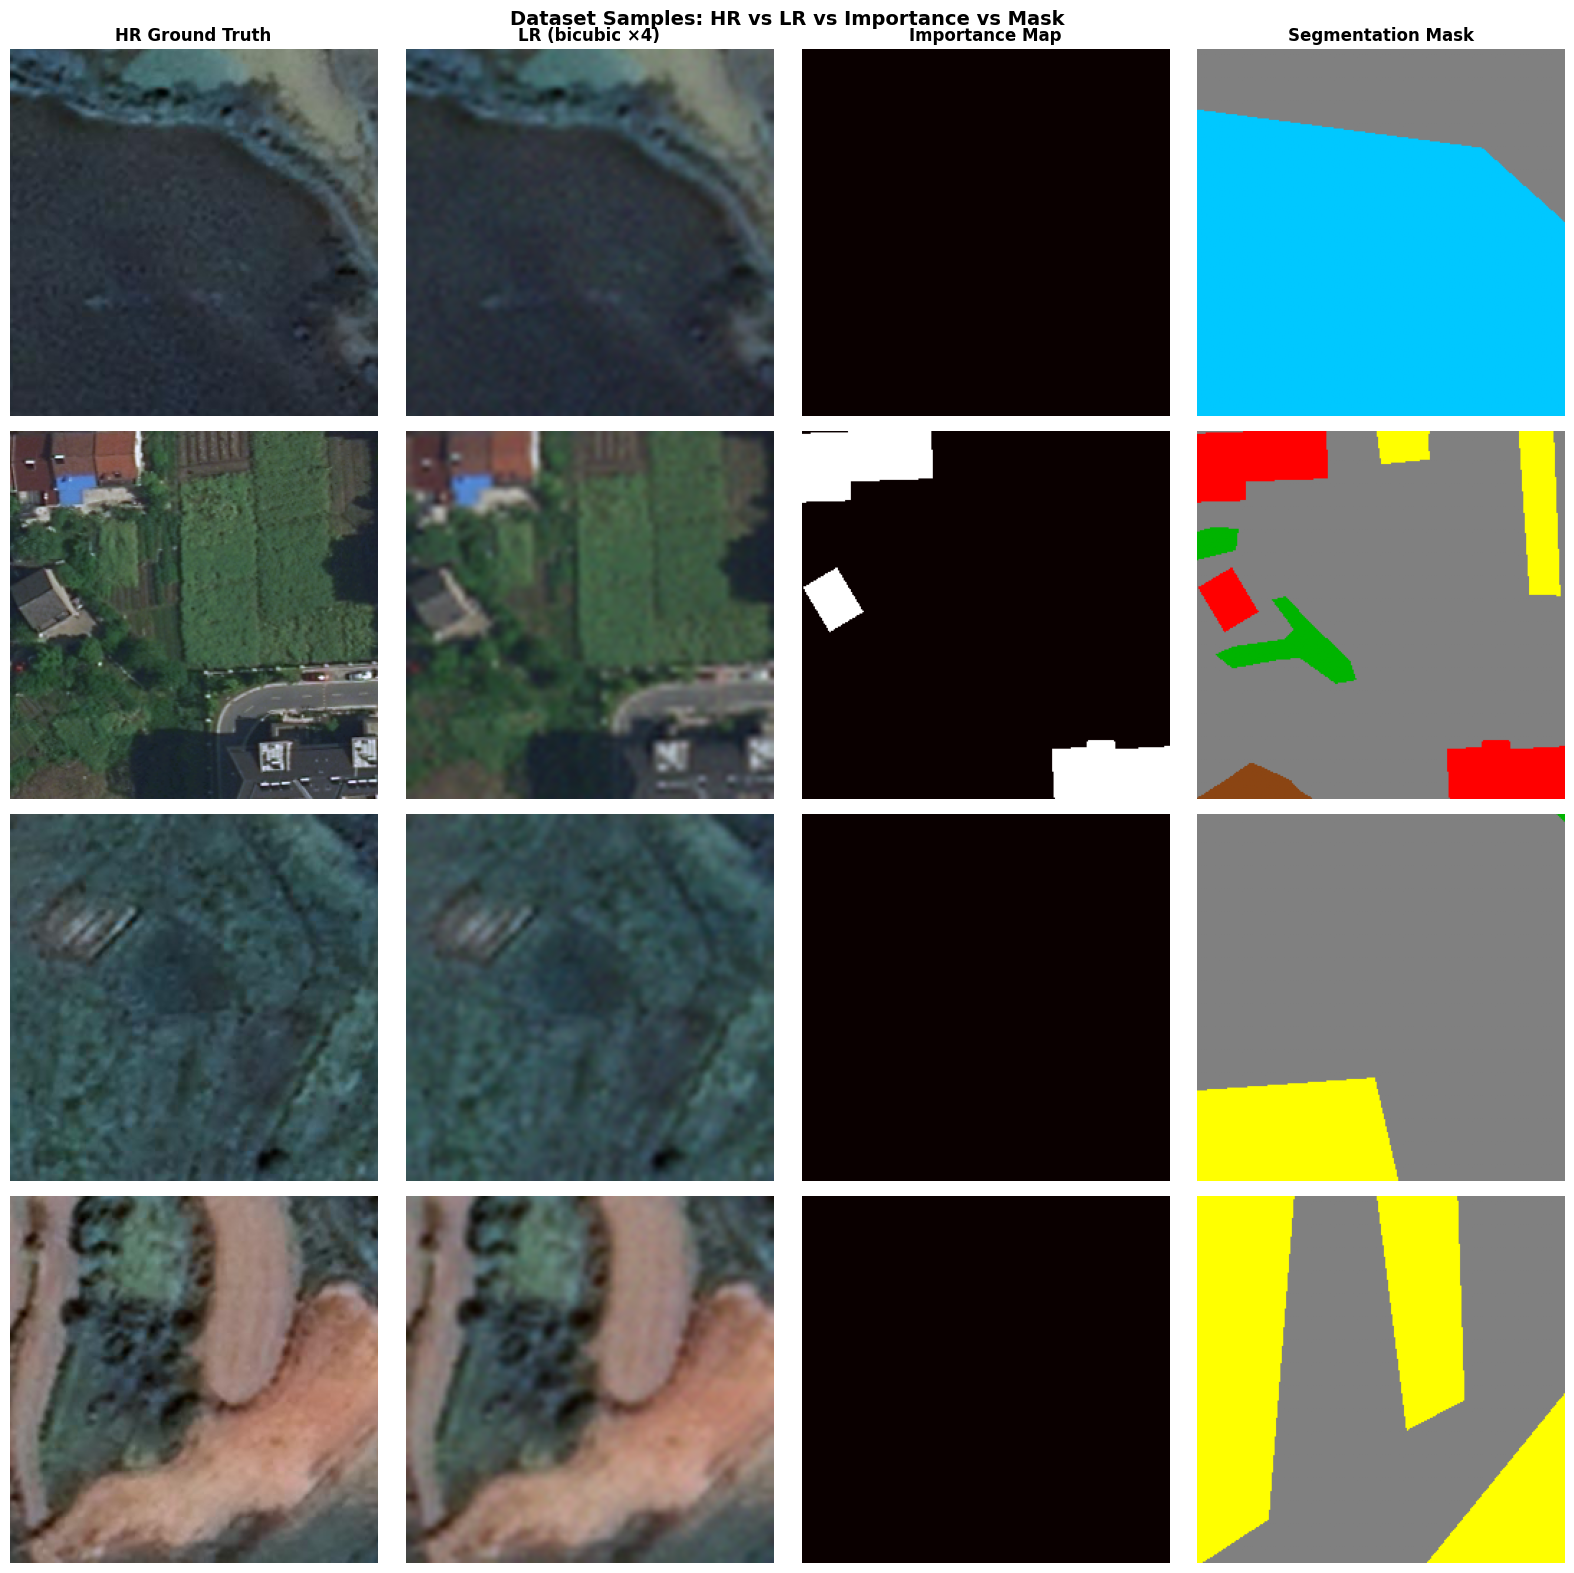

In [3]:
# ==================== DATASET SAMPLE VISUALIZATION ====================
CLASS_NAMES = ['ignore', 'background', 'building', 'road', 'water', 'barren', 'forest', 'agriculture']
CLASS_COLORS = np.array([
    [0, 0, 0],        # 0: ignore
    [128, 128, 128],   # 1: background
    [255, 0, 0],       # 2: building
    [0, 0, 255],       # 3: road
    [0, 200, 255],     # 4: water
    [139, 69, 19],     # 5: barren
    [0, 180, 0],       # 6: forest
    [255, 255, 0],     # 7: agriculture
]) / 255.0

def colorize_mask(m):
    """Convert class-index mask to RGB color image."""
    return CLASS_COLORS[m]

# Show 4 samples: HR | LR (upscaled) | Importance Map | Segmentation Mask
sample_loader = DataLoader(val_dataset, batch_size=4, shuffle=True)
sample = next(iter(sample_loader))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
titles = ['HR Ground Truth', 'LR (bicubic \u00d74)', 'Importance Map', 'Segmentation Mask']
for row in range(4):
    hr = sample['hr'][row].permute(1, 2, 0).numpy()
    lr_up = F.interpolate(sample['lr'][row:row+1], scale_factor=SCALE,
                           mode='bicubic', align_corners=False).clamp(0, 1)[0].permute(1, 2, 0).numpy()
    imp = sample['importance'][row, 0].numpy()
    mask_color = colorize_mask(sample['mask'][row].numpy())
    for col, (img, t) in enumerate(zip([hr, lr_up, imp, mask_color], titles)):
        axes[row, col].imshow(img, cmap='hot' if col == 2 else None)
        if row == 0:
            axes[row, col].set_title(t, fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
plt.suptitle('Dataset Samples: HR vs LR vs Importance vs Mask', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model Architectures

### Shared Building Blocks
- **ConvBlock**: Two Conv2d(3×3) + BN + ReLU layers
- **ResBlock**: Two 3×3 convs with residual connection
- **SEBlock**: Squeeze-excitation channel reweighting
- **WindowAttention**: Non-overlapping 16×16 window multi-head attention (the "heavy" compute)
- **SRBackbone**: Stem → 4 ResBlocks → 2× PixelShuffle upsampling (×4 total)

### Key Models
- **RegionImportanceNet (RIN)**: Lightweight U-Net predicting per-pixel importance from LR input
- **ResNetSegmenter**: ResNet-34 encoder (ImageNet pretrained) + U-Net decoder — much stronger than vanilla SegUNet for reliable task guidance
- **BaselineSRGenerator**: Uniform attention on entire image (comparison point)
- **AdaptiveSRGenerator**: Soft-blend training + hard-gated window routing at inference

In [4]:
# ==================== SHARED BUILDING BLOCKS ====================

class ConvBlock(nn.Module):
    """Two Conv2d(3x3) + BN + ReLU layers."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class ResBlock(nn.Module):
    """Residual block: two 3x3 convs with skip connection."""
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return x + self.conv2(self.act(self.conv1(x)))

class SEBlock(nn.Module):
    """Squeeze-Excitation channel attention."""
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch // reduction), nn.ReLU(inplace=True),
            nn.Linear(ch // reduction, ch), nn.Sigmoid()
        )
    def forward(self, x):
        B, C, _, _ = x.shape
        y = self.pool(x).view(B, C)
        y = self.fc(y).view(B, C, 1, 1)
        return x * y

class WindowAttention(nn.Module):
    """Non-overlapping window multi-head self-attention.
    Partitions feature map into window_size x window_size patches,
    applies MHSA within each window, then reassembles.
    This is the 'heavy' computation path."""
    def __init__(self, dim, window_size=16, num_heads=4):
        super().__init__()
        self.window_size = window_size
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        # Reshape into windows
        xw = x.view(B, C, H // ws, ws, W // ws, ws)
        xw = xw.permute(0, 2, 4, 3, 5, 1).contiguous().view(-1, ws * ws, C)
        normed = self.norm(xw)
        attn_out, _ = self.attn(normed, normed, normed)
        out = xw + attn_out
        # Reassemble
        out = out.view(B, H // ws, W // ws, ws, ws, C)
        out = out.permute(0, 5, 1, 3, 2, 4).contiguous()
        return out.view(B, C, H, W)

class SRBackbone(nn.Module):
    """Shared SR backbone: stem conv -> ResBlocks -> 2x PixelShuffle (x4 total)."""
    def __init__(self, in_ch=3, feat_ch=64, n_resblocks=4, scale=SCALE):
        super().__init__()
        self.stem = nn.Conv2d(in_ch, feat_ch, 3, padding=1)
        self.body = nn.Sequential(*[ResBlock(feat_ch) for _ in range(n_resblocks)])
        self.up1 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch * 4, 3, padding=1), nn.PixelShuffle(2), nn.ReLU(inplace=True)
        )
        self.up2 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch * 4, 3, padding=1), nn.PixelShuffle(2), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        feat = self.stem(x)
        feat = self.body(feat) + feat  # global residual
        feat = self.up1(feat)
        feat = self.up2(feat)
        return feat

print("Building blocks defined.")

Building blocks defined.


In [5]:
# ==================== REGION IMPORTANCE NETWORK (RIN) ====================

class RegionImportanceNet(nn.Module):
    """Lightweight U-Net that predicts per-pixel importance from LR input.
    Output is bilinearly upsampled x4 to HR resolution.
    Supervised with BCE+Dice against GT importance (building/road = 1, else = 0)."""
    def __init__(self, base_ch=32, scale=SCALE):
        super().__init__()
        self.scale = scale
        self.enc1 = ConvBlock(3, base_ch)
        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base_ch * 4, base_ch * 8)
        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = ConvBlock(base_ch * 2, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        imp_lr = torch.sigmoid(self.out_conv(d1))
        return F.interpolate(imp_lr, scale_factor=self.scale, mode='bilinear', align_corners=False)

# ==================== RESNET-34 SEGMENTER ====================

class ResNetSegmenter(nn.Module):
    """ResNet-34 encoder (ImageNet pretrained) + U-Net decoder.
    Much stronger than vanilla SegUNet for reliable task-guidance signal.
    
    Feature maps at 256x256 input:
      enc0: 128x128, 64ch | enc1: 64x64, 64ch | enc2: 32x32, 128ch
      enc3: 16x16, 256ch  | enc4: 8x8, 512ch
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        # Encoder (frozen ImageNet features, unfrozen later layers)
        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # stride 2 -> 128x128, 64ch
        self.pool0 = resnet.maxpool   # stride 2 -> 64x64
        self.enc1 = resnet.layer1     # 64x64, 64ch
        self.enc2 = resnet.layer2     # 32x32, 128ch
        self.enc3 = resnet.layer3     # 16x16, 256ch
        self.enc4 = resnet.layer4     # 8x8, 512ch

        # Decoder with skip connections
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = ConvBlock(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.final_up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.final_block = ConvBlock(32, 32)
        self.out_conv = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        # Encode
        e0 = self.enc0(x)             # 128x128, 64
        e1 = self.enc1(self.pool0(e0))  # 64x64, 64
        e2 = self.enc2(e1)            # 32x32, 128
        e3 = self.enc3(e2)            # 16x16, 256
        e4 = self.enc4(e3)            # 8x8, 512

        # Decode with skips
        d4 = self.dec4(torch.cat([self.up4(e4), e3], 1))  # 16x16, 256
        d3 = self.dec3(torch.cat([self.up3(d4), e2], 1))  # 32x32, 128
        d2 = self.dec2(torch.cat([self.up2(d3), e1], 1))  # 64x64, 64
        d1 = self.dec1(torch.cat([self.up1(d2), e0], 1))  # 128x128, 64
        out = self.final_block(self.final_up(d1))          # 256x256, 32
        return self.out_conv(out)                          # 256x256, num_classes

print("RIN and ResNetSegmenter defined.")

RIN and ResNetSegmenter defined.


In [6]:
# ==================== SR GENERATORS ====================

class BaselineSRGenerator(nn.Module):
    """Uniform SR: runs full attention path on entire image.
    No importance-based routing. Comparison point."""
    def __init__(self, feat_ch=64, window_size=16):
        super().__init__()
        self.backbone = SRBackbone(feat_ch=feat_ch)
        self.attn = WindowAttention(feat_ch, window_size=window_size, num_heads=4)
        self.se = SEBlock(feat_ch)
        self.conv = nn.Conv2d(feat_ch, feat_ch, 3, padding=1)
        self.out_conv = nn.Conv2d(feat_ch, 3, 3, padding=1)

    def forward(self, lr):
        feat = self.backbone(lr)
        feat = self.conv(self.se(self.attn(feat)))
        out = self.out_conv(feat)
        base = F.interpolate(lr, scale_factor=SCALE, mode='bicubic', align_corners=False)
        return torch.clamp(base + out, 0, 1)


class AdaptiveSRGenerator(nn.Module):
    """Region-adaptive SR with dual-branch architecture.
    
    Training mode: differentiable soft blend of heavy + light branches
      blended = importance * heavy + (1 - importance) * light
    
    Inference mode: hard-gated window routing
      - Pool importance map to per-window (16x16) averages
      - Windows above threshold -> heavy path (attention + SE)
      - Windows below threshold -> light path (single conv)
      This achieves actual compute savings.
    """
    def __init__(self, feat_ch=64, window_size=16):
        super().__init__()
        self.backbone = SRBackbone(feat_ch=feat_ch)
        self.window_size = window_size

        # Heavy path: attention + SE + conv
        self.heavy_attn = WindowAttention(feat_ch, window_size=window_size, num_heads=4)
        self.heavy_se = SEBlock(feat_ch)
        self.heavy_conv = nn.Conv2d(feat_ch, feat_ch, 3, padding=1)

        # Light path: single conv + ReLU
        self.light_conv = nn.Sequential(nn.Conv2d(feat_ch, feat_ch, 3, padding=1), nn.ReLU(inplace=True))

        self.out_conv = nn.Conv2d(feat_ch, 3, 3, padding=1)
        self.gate_threshold = 0.5

    def _heavy_path(self, feat):
        """Full attention + SE path."""
        return self.heavy_conv(self.heavy_se(self.heavy_attn(feat)))

    def _hard_gated_forward(self, feat, importance_map):
        """Hard-gated window routing for inference.
        Routes each 16x16 window to either heavy or light path based on
        average importance in that window."""
        B, C, H, W = feat.shape
        ws = self.window_size
        nH, nW = H // ws, W // ws

        # Pool importance to per-window averages
        imp_pooled = F.avg_pool2d(importance_map, ws, stride=ws)  # B, 1, nH, nW

        # Start with light path everywhere (cheap)
        output = self.light_conv(feat.clone())

        # Overwrite high-importance windows with heavy path output
        for b in range(B):
            for i in range(nH):
                for j in range(nW):
                    if imp_pooled[b, 0, i, j] > self.gate_threshold:
                        window_feat = feat[b:b+1, :, i*ws:(i+1)*ws, j*ws:(j+1)*ws]
                        heavy_out = self._heavy_path(window_feat)
                        output[b:b+1, :, i*ws:(i+1)*ws, j*ws:(j+1)*ws] = heavy_out

        return output

    def forward(self, lr, importance_map):
        feat = self.backbone(lr)

        if self.training:
            # Soft blend: differentiable for training
            heavy = self._heavy_path(feat)
            light = self.light_conv(feat)
            blended = importance_map * heavy + (1 - importance_map) * light
        else:
            # Hard gating: actual compute savings at inference
            blended = self._hard_gated_forward(feat, importance_map)

        out = self.out_conv(blended)
        base = F.interpolate(lr, scale_factor=SCALE, mode='bicubic', align_corners=False)
        return torch.clamp(base + out, 0, 1)


print("SR Generators defined (Baseline + Adaptive with hard gating).")

SR Generators defined (Baseline + Adaptive with hard gating).


In [7]:
# ==================== MODEL PARAMETER COUNTS ====================
def count_params(model):
    return sum(p.numel() for p in model.parameters())

rin_tmp = RegionImportanceNet()
seg_tmp = ResNetSegmenter()
baseline_tmp = BaselineSRGenerator()
adaptive_tmp = AdaptiveSRGenerator()

print("="*60)
print(f"{'Model':<30} {'Parameters':>15}")
print("="*60)
print(f"{'RegionImportanceNet (RIN)':<30} {count_params(rin_tmp):>15,}")
print(f"{'ResNetSegmenter':<30} {count_params(seg_tmp):>15,}")
print(f"{'BaselineSRGenerator':<30} {count_params(baseline_tmp):>15,}")
print(f"{'AdaptiveSRGenerator':<30} {count_params(adaptive_tmp):>15,}")
print("="*60)

del rin_tmp, seg_tmp, baseline_tmp, adaptive_tmp
gc.collect()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s]


Model                               Parameters
RegionImportanceNet (RIN)            1,928,417
ResNetSegmenter                     24,452,904
BaselineSRGenerator                    649,163
AdaptiveSRGenerator                    686,091


6

## 4. Loss Functions

**Baseline SR** is trained with: `pixel_loss + 0.5 * edge_loss` (no importance weighting, no task guidance)

**Adaptive SR** is trained with the full composite loss:
```
total = pixel_loss + 0.5 * edge_loss + 0.5 * seg_guided_loss + 0.1 * perceptual_loss
```

| Loss | Purpose |
|------|--------|
| **Pixel (L1)** | Per-pixel fidelity, importance-weighted (4× on buildings/roads) |
| **Edge (Sobel L1)** | Structural/geometric fidelity on important regions |
| **Segmentation-guided** | Frozen segmenter CE — gradients flow into SR generator |
| **VGG Perceptual** | Mid-level texture fidelity via VGG-19 conv3_4 features |

In [8]:
# ==================== LOSS FUNCTIONS ====================

def sobel_edges(img):
    """Compute Sobel edge magnitude for a batch of images."""
    gray = 0.299 * img[:, 0:1] + 0.587 * img[:, 1:2] + 0.114 * img[:, 2:3]
    sx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                      dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    sy = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                      dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    gx = F.conv2d(gray, sx, padding=1)
    gy = F.conv2d(gray, sy, padding=1)
    return torch.sqrt(gx**2 + gy**2 + 1e-6)

def pixel_loss(sr, hr, importance_map, base_weight=1.0, imp_weight=IMPORTANCE_WEIGHT):
    """Importance-weighted L1 loss. Buildings/roads get 4x penalty."""
    diff = torch.abs(sr - hr)
    weight_map = base_weight + imp_weight * importance_map
    return (diff * weight_map).mean()

def edge_loss(sr, hr, importance_map):
    """Sobel edge L1 difference, masked to important regions."""
    diff = torch.abs(sobel_edges(sr) - sobel_edges(hr))
    return (diff * importance_map).sum() / (importance_map.sum() + 1e-6)

# ==================== VGG PERCEPTUAL LOSS ====================

class VGGPerceptualLoss(nn.Module):
    """Perceptual loss using VGG-19 conv3_4 features.
    Captures mid-level texture/structure fidelity."""
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.features = nn.Sequential(*list(vgg.features[:18]))  # up to conv3_4
        for p in self.features.parameters():
            p.requires_grad = False
        # ImageNet normalization
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def normalize(self, x):
        return (x - self.mean) / self.std

    def forward(self, sr, hr):
        return F.l1_loss(self.features(self.normalize(sr)), self.features(self.normalize(hr)))

# ==================== COMPOSITE LOSSES ====================

ce_loss = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def seg_guided_loss(sr, mask, seg_model):
    """Task-guided loss: CE of frozen segmenter predictions on SR output.
    Segmenter weights don't update, but gradients flow into the SR generator."""
    logits = seg_model(sr)
    return ce_loss(logits, mask)

def total_adaptive_loss(sr, hr, mask, importance_map, seg_model, perceptual_loss_fn):
    """Full composite loss for Adaptive SR training."""
    l_pixel = pixel_loss(sr, hr, importance_map)
    l_edge = edge_loss(sr, hr, importance_map)
    l_seg = seg_guided_loss(sr, mask, seg_model)
    l_percep = perceptual_loss_fn(sr, hr)
    total = l_pixel + LAMBDA_EDGE * l_edge + LAMBDA_SEG * l_seg + LAMBDA_PERCEPTUAL * l_percep
    return total, {
        'pixel': l_pixel.item(), 'edge': l_edge.item(),
        'seg': l_seg.item(), 'perceptual': l_percep.item()
    }

def total_baseline_loss(sr, hr, importance_map):
    """Baseline loss: pixel + edge only (no task guidance, uniform importance)."""
    l_pixel = pixel_loss(sr, hr, importance_map)
    l_edge = edge_loss(sr, hr, importance_map)
    total = l_pixel + LAMBDA_EDGE * l_edge
    return total, {'pixel': l_pixel.item(), 'edge': l_edge.item()}

def compute_miou(pred_logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    """Mean IoU over all non-ignored classes."""
    pred = pred_logits.argmax(1)
    ious = []
    for c in range(num_classes):
        if c == ignore_index:
            continue
        pred_c, target_c = (pred == c), (target == c)
        inter = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        if union == 0:
            continue
        ious.append(inter / union)
    return sum(ious) / len(ious) if ious else 0.0

def compute_per_class_iou(pred_logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    """Per-class IoU (returns dict)."""
    pred = pred_logits.argmax(1)
    result = {}
    for c in range(num_classes):
        if c == ignore_index:
            continue
        pred_c, target_c = (pred == c), (target == c)
        inter = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        result[CLASS_NAMES[c]] = inter / union if union > 0 else float('nan')
    return result

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr).item()
    return 100.0 if mse == 0 else 10 * np.log10(1.0 / mse)

print("Loss functions defined.")

Loss functions defined.


## 5. Training Pipeline

Training happens in **strict stages**, each depending on the previous being frozen:

1. **RIN** (20 epochs, Adam lr=5e-4, ReduceLROnPlateau) — learns where buildings/roads are
2. **Segmenter** (30 epochs, Adam lr=3e-4) — learns to segment land cover from HR images
3. **Baseline SR** (30 epochs, Adam lr=1e-4, CosineAnnealingLR) — uniform attention, no task loss
4. **Adaptive SR** (50 epochs, Adam lr=1e-4, CosineAnnealingLR) — full pipeline with all losses

> **Note:** Each training stage saves `*_best.pth` (on metric improvement) and `*_latest.pth` (every epoch for resumption). Training is wrapped in try/except to preserve checkpoints on crash.

In [9]:
# ==================== STAGE 1: TRAIN RIN ====================
print("="*60)
print("STAGE 1: Training Region Importance Network (RIN)")
print("="*60)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

rin = RegionImportanceNet().to(device)
rin_opt = optim.Adam(rin.parameters(), lr=5e-4)
rin_sched = optim.lr_scheduler.ReduceLROnPlateau(rin_opt, mode='min', factor=0.5, patience=3)
bce_loss = nn.BCELoss()
scaler = GradScaler('cuda', enabled=USE_AMP)

def dice_loss(pred, target, smooth=1.0):
    pred_flat, target_flat = pred.view(-1), target.view(-1)
    inter = (pred_flat * target_flat).sum()
    return 1 - (2 * inter + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

best_rin_val = float('inf')
rin_ckpt_path = os.path.join(CKPT_DIR, 'rin_best.pth')

for epoch in range(1, RIN_EPOCHS + 1):
    rin.train()
    t0 = time.time()
    running = 0.0
    for batch in train_loader:
        lr_img = batch['lr'].to(device, non_blocking=True)
        importance = batch['importance'].to(device, non_blocking=True)
        rin_opt.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            pred = rin(lr_img)
        # BCE is unsafe under autocast — compute in float32
        pred_f, imp_f = pred.float(), importance.float()
        loss = bce_loss(pred_f, imp_f) + dice_loss(pred_f, imp_f)
        scaler.scale(loss).backward()
        scaler.step(rin_opt)
        scaler.update()
        running += loss.item() * lr_img.size(0)
    train_loss = running / len(train_dataset)

    rin.eval()
    val_running = 0.0
    with torch.no_grad():
        for batch in val_loader:
            lr_img = batch['lr'].to(device, non_blocking=True)
            importance = batch['importance'].to(device, non_blocking=True)
            with autocast('cuda', enabled=USE_AMP):
                pred = rin(lr_img)
            pred_f, imp_f = pred.float(), importance.float()
            loss = bce_loss(pred_f, imp_f) + dice_loss(pred_f, imp_f)
            val_running += loss.item() * lr_img.size(0)
    val_loss = val_running / len(val_dataset)
    rin_sched.step(val_loss)

    print(f"[RIN] Epoch {epoch:02d}/{RIN_EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | {time.time()-t0:.1f}s", flush=True)

    torch.save({'epoch': epoch, 'model_state_dict': rin.state_dict()},
               os.path.join(CKPT_DIR, 'rin_latest.pth'))
    if val_loss < best_rin_val:
        best_rin_val = val_loss
        torch.save({'model_state_dict': rin.state_dict(), 'val_loss': val_loss}, rin_ckpt_path)
        print(f"  -> saved rin_best.pth (val_loss={val_loss:.4f})")

# Freeze RIN
rin.load_state_dict(torch.load(rin_ckpt_path, weights_only=False)['model_state_dict'])
rin.eval()
for p in rin.parameters():
    p.requires_grad = False
print(f"\nRIN trained and frozen. Best val_loss: {best_rin_val:.4f}")

# Aggressive cleanup
del rin_opt, rin_sched, scaler, train_loader, val_loader
gc.collect(); torch.cuda.empty_cache()
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

STAGE 1: Training Region Importance Network (RIN)
[RIN] Epoch 01/20 | train_loss 1.1123 | val_loss 1.2870 | 141.2s
  -> saved rin_best.pth (val_loss=1.2870)
[RIN] Epoch 02/20 | train_loss 0.9698 | val_loss 0.9876 | 113.4s
  -> saved rin_best.pth (val_loss=0.9876)
[RIN] Epoch 03/20 | train_loss 0.9077 | val_loss 1.1453 | 112.0s
[RIN] Epoch 04/20 | train_loss 0.8766 | val_loss 1.1981 | 113.3s
[RIN] Epoch 05/20 | train_loss 0.8402 | val_loss 1.0943 | 111.4s
[RIN] Epoch 06/20 | train_loss 0.8601 | val_loss 0.8403 | 112.2s
  -> saved rin_best.pth (val_loss=0.8403)
[RIN] Epoch 07/20 | train_loss 0.8221 | val_loss 0.9345 | 112.3s
[RIN] Epoch 08/20 | train_loss 0.7991 | val_loss 0.7804 | 109.9s
  -> saved rin_best.pth (val_loss=0.7804)
[RIN] Epoch 09/20 | train_loss 0.8177 | val_loss 0.9587 | 108.4s
[RIN] Epoch 10/20 | train_loss 0.8065 | val_loss 0.8042 | 110.8s
[RIN] Epoch 11/20 | train_loss 0.8060 | val_loss 1.1576 | 112.8s
[RIN] Epoch 12/20 | train_loss 0.8206 | val_loss 0.8937 | 112.5s
[R

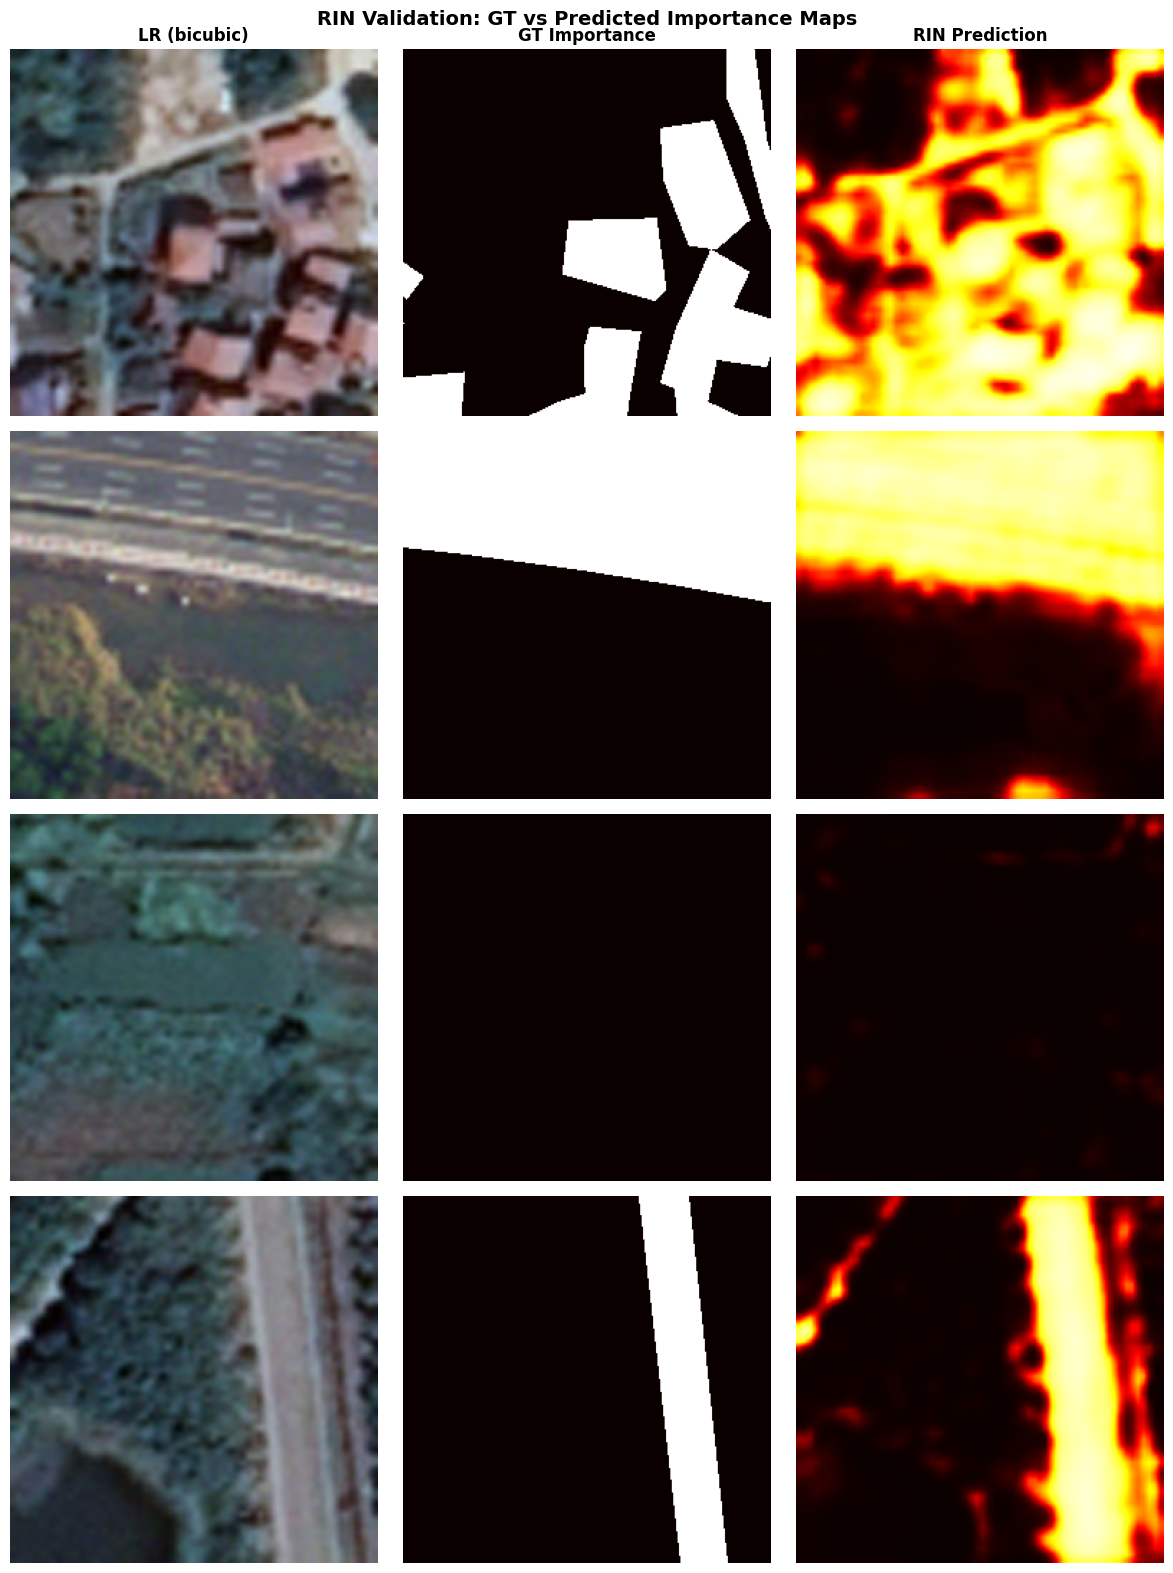

In [10]:
# ==================== RIN VALIDATION VISUALIZATION ====================
rin.eval()
sample_batch = next(iter(DataLoader(val_dataset, batch_size=4, shuffle=True)))
with torch.no_grad():
    pred_imp = rin(sample_batch['lr'].to(device))

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for row in range(4):
    lr_up = F.interpolate(sample_batch['lr'][row:row+1], scale_factor=SCALE,
                           mode='bicubic', align_corners=False).clamp(0, 1)
    axes[row, 0].imshow(lr_up[0].permute(1, 2, 0).numpy())
    axes[row, 1].imshow(sample_batch['importance'][row, 0].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[row, 2].imshow(pred_imp[row, 0].cpu().numpy(), cmap='hot', vmin=0, vmax=1)
    if row == 0:
        axes[row, 0].set_title('LR (bicubic)', fontsize=12, fontweight='bold')
        axes[row, 1].set_title('GT Importance', fontsize=12, fontweight='bold')
        axes[row, 2].set_title('RIN Prediction', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off'); axes[row, 1].axis('off'); axes[row, 2].axis('off')
plt.suptitle('RIN Validation: GT vs Predicted Importance Maps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ==================== STAGE 2: TRAIN RESNET SEGMENTER ====================
print("="*60)
print("STAGE 2: Training ResNet-34 Segmenter")
print("="*60)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

seg_model = ResNetSegmenter().to(device)
seg_opt = optim.Adam(seg_model.parameters(), lr=3e-4)
seg_sched = optim.lr_scheduler.ReduceLROnPlateau(seg_opt, mode='min', factor=0.5, patience=3)
scaler = GradScaler('cuda', enabled=USE_AMP)

best_seg_val = float('inf')
seg_ckpt_path = os.path.join(CKPT_DIR, 'segmenter_best.pth')

for epoch in range(1, SEG_EPOCHS + 1):
    seg_model.train()
    t0 = time.time()
    running = 0.0
    for batch in train_loader:
        hr = batch['hr'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        seg_opt.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            logits = seg_model(hr)
            loss = ce_loss(logits, mask)
        scaler.scale(loss).backward()
        scaler.step(seg_opt)
        scaler.update()
        running += loss.item() * hr.size(0)
    train_loss = running / len(train_dataset)

    seg_model.eval()
    val_running, miou_sum = 0.0, 0.0
    all_per_class = {name: [] for name in CLASS_NAMES[1:]}
    with torch.no_grad():
        for batch in val_loader:
            hr = batch['hr'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)
            with autocast('cuda', enabled=USE_AMP):
                logits = seg_model(hr)
                loss = ce_loss(logits, mask)
            val_running += loss.item() * hr.size(0)
            miou_sum += compute_miou(logits.float(), mask) * hr.size(0)
            pc = compute_per_class_iou(logits.float(), mask)
            for k, v in pc.items():
                if not np.isnan(v):
                    all_per_class[k].append(v)
    val_loss = val_running / len(val_dataset)
    val_miou = miou_sum / len(val_dataset)
    seg_sched.step(val_loss)

    print(f"[Seg] Epoch {epoch:02d}/{SEG_EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_mIoU {val_miou:.4f} | {time.time()-t0:.1f}s", flush=True)

    torch.save({'epoch': epoch, 'model_state_dict': seg_model.state_dict(), 'val_miou': val_miou},
               os.path.join(CKPT_DIR, 'segmenter_latest.pth'))
    if val_loss < best_seg_val:
        best_seg_val = val_loss
        torch.save({'model_state_dict': seg_model.state_dict(), 'val_loss': val_loss, 'val_miou': val_miou},
                   seg_ckpt_path)
        print(f"  -> saved segmenter_best.pth (mIoU={val_miou:.4f})")

# Print final per-class IoU
print("\n" + "="*50)
print("Segmenter Per-Class IoU on Val Set (HR images):")
print("="*50)
for name in CLASS_NAMES[1:]:
    vals = all_per_class[name]
    if vals:
        print(f"  {name:<15} IoU = {np.mean(vals):.4f}")
print(f"  {'mIoU':<15}     = {val_miou:.4f}")
print("="*50)

# Freeze segmenter
seg_model.load_state_dict(torch.load(seg_ckpt_path, weights_only=False)['model_state_dict'])
seg_model.eval()
for p in seg_model.parameters():
    p.requires_grad = False
print(f"\nSegmenter trained and frozen. Best val_loss: {best_seg_val:.4f}")

# Aggressive cleanup
del seg_opt, seg_sched, scaler, train_loader, val_loader
gc.collect(); torch.cuda.empty_cache()
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

STAGE 2: Training ResNet-34 Segmenter
[Seg] Epoch 01/30 | train_loss 1.5195 | val_loss 1.5265 | val_mIoU 0.2061 | 110.3s
  -> saved segmenter_best.pth (mIoU=0.2061)
[Seg] Epoch 02/30 | train_loss 1.2461 | val_loss 1.4789 | val_mIoU 0.2169 | 110.7s
  -> saved segmenter_best.pth (mIoU=0.2169)
[Seg] Epoch 03/30 | train_loss 1.1277 | val_loss 1.4404 | val_mIoU 0.2110 | 111.0s
  -> saved segmenter_best.pth (mIoU=0.2110)
[Seg] Epoch 04/30 | train_loss 1.0384 | val_loss 1.2454 | val_mIoU 0.2846 | 109.8s
  -> saved segmenter_best.pth (mIoU=0.2846)
[Seg] Epoch 05/30 | train_loss 1.0097 | val_loss 1.4832 | val_mIoU 0.2454 | 109.5s
[Seg] Epoch 06/30 | train_loss 0.9588 | val_loss 1.2570 | val_mIoU 0.3250 | 113.0s
[Seg] Epoch 07/30 | train_loss 0.9295 | val_loss 1.2164 | val_mIoU 0.2727 | 116.5s
  -> saved segmenter_best.pth (mIoU=0.2727)
[Seg] Epoch 08/30 | train_loss 0.9152 | val_loss 1.1547 | val_mIoU 0.3227 | 114.9s
  -> saved segmenter_best.pth (mIoU=0.3227)
[Seg] Epoch 09/30 | train_loss 0.8

In [12]:
# ==================== SR TRAINING UTILITY (MEMORY-OPTIMIZED) ====================

# Smaller-batch loaders for SR training
sr_train_loader = DataLoader(train_dataset, batch_size=SR_BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
sr_val_loader = DataLoader(val_dataset, batch_size=SR_BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

# Initialize VGG perceptual loss
perceptual_loss_fn = VGGPerceptualLoss().to(device)
perceptual_loss_fn.eval()

# Gradient accumulation to simulate larger batch with less memory
ACCUM_STEPS = 2  # effective batch = SR_BATCH_SIZE * ACCUM_STEPS = 8

def train_sr_model(model, model_name, use_importance, use_task_loss, epochs, lr=1e-4):
    """SR training with AMP + gradient accumulation + crash recovery."""
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_latest.pth')
    best_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15, eta_min=1e-6)
    scaler = GradScaler('cuda', enabled=USE_AMP)

    start_epoch = 1
    best_psnr = 0.0
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, weights_only=False)
        model.load_state_dict(ck['model_state_dict'])
        opt.load_state_dict(ck['optimizer_state_dict'])
        start_epoch = ck['epoch'] + 1
        best_psnr = ck.get('best_psnr', 0.0)
        print(f"[{model_name}] Resuming from epoch {start_epoch}")

    try:
        for epoch in range(start_epoch, epochs + 1):
            model.train()
            t0 = time.time()
            running_loss = 0.0
            opt.zero_grad()

            for step, batch in enumerate(sr_train_loader):
                lr_img = batch['lr'].to(device, non_blocking=True)
                hr_img = batch['hr'].to(device, non_blocking=True)
                mask = batch['mask'].to(device, non_blocking=True)

                with autocast('cuda', enabled=USE_AMP):
                    if use_importance:
                        with torch.no_grad():
                            importance = rin(lr_img)
                        sr = model(lr_img, importance)
                    else:
                        importance = torch.ones(lr_img.size(0), 1, HR_PATCH, HR_PATCH,
                                               device=device)
                        sr = model(lr_img)

                    if use_task_loss:
                        loss, parts = total_adaptive_loss(sr, hr_img, mask, importance,
                                                          seg_model, perceptual_loss_fn)
                    else:
                        loss, parts = total_baseline_loss(sr, hr_img, importance)

                    loss = loss / ACCUM_STEPS  # scale for accumulation

                scaler.scale(loss).backward()

                if (step + 1) % ACCUM_STEPS == 0:
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad()

                running_loss += loss.item() * ACCUM_STEPS * lr_img.size(0)

                # Free intermediate tensors
                del sr, loss, lr_img, hr_img, mask, importance
                if use_task_loss:
                    del parts

            train_loss = running_loss / len(train_dataset)
            sched.step()

            # Validation
            model.eval()
            val_psnr_sum, n = 0.0, 0
            with torch.no_grad():
                for batch in sr_val_loader:
                    lr_img = batch['lr'].to(device, non_blocking=True)
                    hr_img = batch['hr'].to(device, non_blocking=True)
                    with autocast('cuda', enabled=USE_AMP):
                        if use_importance:
                            importance = rin(lr_img)
                            sr = model(lr_img, importance)
                        else:
                            sr = model(lr_img)
                    val_psnr_sum += psnr(sr.float(), hr_img) * lr_img.size(0)
                    n += lr_img.size(0)
                    del sr, lr_img, hr_img
            val_psnr = val_psnr_sum / n

            elapsed = time.time() - t0
            lr_now = opt.param_groups[0]['lr']
            print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                  f"train_loss {train_loss:.4f} | val_PSNR {val_psnr:.2f}dB | "
                  f"lr {lr_now:.2e} | {elapsed:.1f}s | "
                  f"GPU {torch.cuda.memory_allocated()/1e9:.1f}GB", flush=True)

            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': opt.state_dict(),
                        'best_psnr': max(best_psnr, val_psnr)}, ckpt_path)
            if val_psnr > best_psnr:
                best_psnr = val_psnr
                torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                            'val_psnr': val_psnr}, best_path)
                print(f"  -> new best {model_name} (PSNR={val_psnr:.2f}dB)")

            torch.cuda.empty_cache()

    except torch.cuda.OutOfMemoryError as e:
        print(f"\n[{model_name}] OOM! Current SR_BATCH_SIZE={SR_BATCH_SIZE}")
        print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")
        print("Try reducing SR_BATCH_SIZE to 2 and rerun this cell.")
        torch.cuda.empty_cache(); gc.collect()
    except Exception as e:
        print(f"[{model_name}] Training interrupted: {e}")
        print(f"Checkpoint preserved at {ckpt_path}, safe to resume.")

    del opt, sched, scaler
    gc.collect(); torch.cuda.empty_cache()
    return best_psnr

print(f"SR training utility ready. Effective batch = {SR_BATCH_SIZE} x {ACCUM_STEPS} = {SR_BATCH_SIZE * ACCUM_STEPS}")
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 205MB/s]


SR training utility ready. Effective batch = 4 x 2 = 8
GPU mem: 0.24 GB


In [13]:
# ==================== STAGE 3: TRAIN BASELINE SR ====================
print("="*60)
print("STAGE 3: Baseline SR (uniform attention, no task guidance)")
print("="*60)

baseline_gen = BaselineSRGenerator().to(device)
best_baseline_psnr = train_sr_model(
    baseline_gen, 'baseline_sr',
    use_importance=False, use_task_loss=False,
    epochs=BASELINE_SR_EPOCHS, lr=1e-4
)

# Move baseline to CPU to free GPU for adaptive training
baseline_gen.cpu()
torch.cuda.empty_cache(); gc.collect()
print(f"\nBaseline SR done. Best PSNR: {best_baseline_psnr:.2f} dB")
print(f"GPU mem after offload: {torch.cuda.memory_allocated()/1e9:.2f} GB")

STAGE 3: Baseline SR (uniform attention, no task guidance)
[baseline_sr] Epoch 01/30 | train_loss 0.1355 | val_PSNR 31.63dB | lr 9.89e-05 | 137.5s | GPU 0.3GB
  -> new best baseline_sr (PSNR=31.63dB)
[baseline_sr] Epoch 02/30 | train_loss 0.1289 | val_PSNR 31.76dB | lr 9.57e-05 | 135.8s | GPU 0.3GB
  -> new best baseline_sr (PSNR=31.76dB)
[baseline_sr] Epoch 03/30 | train_loss 0.1260 | val_PSNR 31.82dB | lr 9.05e-05 | 136.4s | GPU 0.3GB
  -> new best baseline_sr (PSNR=31.82dB)
[baseline_sr] Epoch 04/30 | train_loss 0.1249 | val_PSNR 31.75dB | lr 8.36e-05 | 135.1s | GPU 0.3GB
[baseline_sr] Epoch 05/30 | train_loss 0.1249 | val_PSNR 32.05dB | lr 7.52e-05 | 135.3s | GPU 0.3GB
  -> new best baseline_sr (PSNR=32.05dB)
[baseline_sr] Epoch 06/30 | train_loss 0.1250 | val_PSNR 31.79dB | lr 6.58e-05 | 135.0s | GPU 0.3GB
[baseline_sr] Epoch 07/30 | train_loss 0.1242 | val_PSNR 31.97dB | lr 5.57e-05 | 134.4s | GPU 0.3GB
[baseline_sr] Epoch 08/30 | train_loss 0.1241 | val_PSNR 31.92dB | lr 4.53e-0

In [14]:
# ==================== STAGE 4: TRAIN ADAPTIVE SR ====================
print("="*60)
print("STAGE 4: Adaptive SR (RIN-guided + task-guided + perceptual loss)")
print("="*60)

adaptive_gen = AdaptiveSRGenerator().to(device)
best_adaptive_psnr = train_sr_model(
    adaptive_gen, 'adaptive_sr',
    use_importance=True, use_task_loss=True,
    epochs=ADAPTIVE_SR_EPOCHS, lr=1e-4
)

# Move adaptive to CPU, free VGG perceptual loss
adaptive_gen.cpu()
perceptual_loss_fn.cpu()
del sr_train_loader, sr_val_loader
torch.cuda.empty_cache(); gc.collect()

print(f"\nAdaptive SR done. Best PSNR: {best_adaptive_psnr:.2f} dB")
print("="*60)
print(f"TRAINING COMPLETE")
print(f"  Baseline best PSNR: {best_baseline_psnr:.2f} dB")
print(f"  Adaptive best PSNR: {best_adaptive_psnr:.2f} dB")
print("="*60)
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")

STAGE 4: Adaptive SR (RIN-guided + task-guided + perceptual loss)
[adaptive_sr] Epoch 01/50 | train_loss 0.6810 | val_PSNR 28.88dB | lr 9.89e-05 | 228.7s | GPU 0.3GB
  -> new best adaptive_sr (PSNR=28.88dB)
[adaptive_sr] Epoch 02/50 | train_loss 0.6415 | val_PSNR 29.48dB | lr 9.57e-05 | 226.7s | GPU 0.3GB
  -> new best adaptive_sr (PSNR=29.48dB)
[adaptive_sr] Epoch 03/50 | train_loss 0.6259 | val_PSNR 29.35dB | lr 9.05e-05 | 225.7s | GPU 0.3GB
[adaptive_sr] Epoch 04/50 | train_loss 0.6132 | val_PSNR 29.46dB | lr 8.36e-05 | 225.5s | GPU 0.3GB
[adaptive_sr] Epoch 05/50 | train_loss 0.6016 | val_PSNR 29.88dB | lr 7.52e-05 | 226.1s | GPU 0.3GB
  -> new best adaptive_sr (PSNR=29.88dB)
[adaptive_sr] Epoch 06/50 | train_loss 0.5953 | val_PSNR 29.88dB | lr 6.58e-05 | 225.7s | GPU 0.3GB
[adaptive_sr] Epoch 07/50 | train_loss 0.5918 | val_PSNR 30.00dB | lr 5.57e-05 | 228.9s | GPU 0.3GB
  -> new best adaptive_sr (PSNR=30.00dB)
[adaptive_sr] Epoch 08/50 | train_loss 0.5852 | val_PSNR 29.93dB | lr 

## 6. Comprehensive Evaluation

Compare **bicubic / baseline / adaptive** against ground truth on the validation set.

### Metrics
| Metric | Description |
|--------|------------|
| **PSNR** | Peak signal-to-noise ratio (pixel fidelity) |
| **SSIM** | Structural similarity |
| **Edge IoU** | Canny edge overlap (geometric fidelity) |
| **Seg mIoU** | Segmentation quality on SR output (downstream utility) |
| **Per-class IoU** | Breakdown by land-cover class (building/road are key) |
| **FLOPs** | Computational cost (effective FLOPs for adaptive) |
| **Inference time** | Wall-clock time per image |

In [15]:
# ==================== LOAD BEST CHECKPOINTS FOR EVALUATION ====================
!pip install -q scikit-image fvcore iopath
from skimage.metrics import structural_similarity as ssim_fn

# Reload best checkpoints onto GPU
baseline_gen = BaselineSRGenerator().to(device)
baseline_gen.load_state_dict(
    torch.load(os.path.join(CKPT_DIR, 'baseline_sr_best.pth'), weights_only=False)['model_state_dict'])
baseline_gen.eval()

adaptive_gen = AdaptiveSRGenerator().to(device)
adaptive_gen.load_state_dict(
    torch.load(os.path.join(CKPT_DIR, 'adaptive_sr_best.pth'), weights_only=False)['model_state_dict'])
adaptive_gen.eval()

rin.to(device)
seg_model.to(device)

for m in [rin, seg_model, baseline_gen, adaptive_gen]:
    m.eval()
    for p in m.parameters():
        p.requires_grad = False

print("All models loaded in eval mode.")
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ==================== EVALUATION UTILITIES ====================
def to_numpy_img(t):
    return t.permute(1, 2, 0).cpu().numpy()

def batch_ssim(sr, hr):
    scores = []
    for i in range(sr.size(0)):
        scores.append(ssim_fn(to_numpy_img(hr[i]), to_numpy_img(sr[i]),
                              channel_axis=2, data_range=1.0))
    return np.mean(scores)

def canny_edge_iou(sr, hr):
    ious = []
    for i in range(sr.size(0)):
        s_gray = (0.299*sr[i,0] + 0.587*sr[i,1] + 0.114*sr[i,2]).cpu().numpy()
        h_gray = (0.299*hr[i,0] + 0.587*hr[i,1] + 0.114*hr[i,2]).cpu().numpy()
        s_edge = cv2.Canny((s_gray * 255).astype(np.uint8), 50, 150) > 0
        h_edge = cv2.Canny((h_gray * 255).astype(np.uint8), 50, 150) > 0
        inter, union = (s_edge & h_edge).sum(), (s_edge | h_edge).sum()
        ious.append(inter / union if union > 0 else 1.0)
    return np.mean(ious)

print("Evaluation utilities ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 489.5 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All models loaded in eval mode.
GPU memory: 0.25 GB
Evaluation utilities ready.


In [16]:
# ==================== FULL EVALUATION (MEMORY-SAFE) ====================
test_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=NUM_WORKERS)

results = {k: {'psnr': [], 'ssim': [], 'edge_iou': [], 'miou': []}
           for k in ['bicubic', 'baseline', 'adaptive']}
per_class_results = {k: {name: [] for name in CLASS_NAMES[1:]}
                     for k in ['bicubic', 'baseline', 'adaptive', 'gt']}
gt_miou = []
tier_high, tier_med, tier_low = [], [], []

print("Running full evaluation on validation set...")
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        lr_img = batch['lr'].to(device)
        hr_img = batch['hr'].to(device)
        mask = batch['mask'].to(device)

        with autocast('cuda', enabled=USE_AMP):
            bicubic_sr = F.interpolate(lr_img, scale_factor=SCALE,
                                        mode='bicubic', align_corners=False).clamp(0, 1)
            baseline_sr = baseline_gen(lr_img)
            importance = rin(lr_img)
            adaptive_sr = adaptive_gen(lr_img, importance)

        # Cast back to float32 for metrics
        bicubic_sr, baseline_sr, adaptive_sr = bicubic_sr.float(), baseline_sr.float(), adaptive_sr.float()

        # Tier usage statistics
        imp_flat = importance.cpu().numpy().flatten()
        tier_high.append((imp_flat > 0.66).mean())
        tier_med.append(((imp_flat > 0.33) & (imp_flat <= 0.66)).mean())
        tier_low.append((imp_flat <= 0.33).mean())

        for name, sr in [('bicubic', bicubic_sr), ('baseline', baseline_sr),
                          ('adaptive', adaptive_sr)]:
            results[name]['psnr'].append(psnr(sr, hr_img))
            results[name]['ssim'].append(batch_ssim(sr, hr_img))
            results[name]['edge_iou'].append(canny_edge_iou(sr, hr_img))

            with autocast('cuda', enabled=USE_AMP):
                seg_logits = seg_model(sr)
            results[name]['miou'].append(compute_miou(seg_logits.float(), mask))
            pc = compute_per_class_iou(seg_logits.float(), mask)
            for k, v in pc.items():
                if not np.isnan(v):
                    per_class_results[name][k].append(v)
            del seg_logits

        with autocast('cuda', enabled=USE_AMP):
            gt_logits = seg_model(hr_img)
        gt_miou.append(compute_miou(gt_logits.float(), mask))
        pc_gt = compute_per_class_iou(gt_logits.float(), mask)
        for k, v in pc_gt.items():
            if not np.isnan(v):
                per_class_results['gt'][k].append(v)

        del lr_img, hr_img, mask, bicubic_sr, baseline_sr, adaptive_sr, importance, gt_logits
        if (batch_idx + 1) % 50 == 0:
            torch.cuda.empty_cache()
            print(f"  Evaluated {(batch_idx + 1) * 4} / {len(val_dataset)} samples... "
                  f"GPU {torch.cuda.memory_allocated()/1e9:.1f}GB")

print("Evaluation complete!\n")

# ==================== RESULTS TABLES ====================
print("="*80)
print(f"{'Method':<18} {'PSNR (dB)':<12} {'SSIM':<10} {'Edge IoU':<12} {'Seg mIoU':<10}")
print("="*80)
for name in ['bicubic', 'baseline', 'adaptive']:
    r = results[name]
    print(f"{name:<18} {np.mean(r['psnr']):<12.2f} {np.mean(r['ssim']):<10.4f} "
          f"{np.mean(r['edge_iou']):<12.4f} {np.mean(r['miou']):<10.4f}")
print(f"{'GT (upper bound)':<18} {'--':<12} {'--':<10} {'--':<12} {np.mean(gt_miou):<10.4f}")
print("="*80)

# Per-class segmentation IoU table
print(f"\n{'='*85}")
print(f"{'Per-Class Seg IoU':<18}", end='')
for name in ['bicubic', 'baseline', 'adaptive', 'gt']:
    print(f"{name:<14}", end='')
print()
print("="*85)
for cls in CLASS_NAMES[1:]:
    print(f"{cls:<18}", end='')
    for name in ['bicubic', 'baseline', 'adaptive', 'gt']:
        vals = per_class_results[name][cls]
        val = np.mean(vals) if vals else float('nan')
        print(f"{val:<14.4f}", end='')
    print()
print("="*85)

# Importance tier usage
print(f"\nImportance Map Tier Distribution (val set average):")
print(f"  High (>0.66): {np.mean(tier_high)*100:.1f}%")
print(f"  Med  (0.33-0.66): {np.mean(tier_med)*100:.1f}%")
print(f"  Low  (<0.33): {np.mean(tier_low)*100:.1f}%")

Running full evaluation on validation set...
  Evaluated 200 / 1669 samples... GPU 0.3GB
  Evaluated 400 / 1669 samples... GPU 0.3GB
  Evaluated 600 / 1669 samples... GPU 0.3GB
  Evaluated 800 / 1669 samples... GPU 0.3GB
  Evaluated 1000 / 1669 samples... GPU 0.3GB
  Evaluated 1200 / 1669 samples... GPU 0.3GB
  Evaluated 1400 / 1669 samples... GPU 0.3GB
  Evaluated 1600 / 1669 samples... GPU 0.3GB
Evaluation complete!

Method             PSNR (dB)    SSIM       Edge IoU     Seg mIoU  
bicubic            30.81        0.8103     0.0862       0.1700    
baseline           32.06        0.8458     0.1920       0.1736    
adaptive           30.70        0.7928     0.1728       0.2828    
GT (upper bound)   --           --         --           0.3096    

Per-Class Seg IoU bicubic       baseline      adaptive      gt            
background        0.4194        0.4136        0.4450        0.4690        
building          0.1405        0.1921        0.3005        0.3692        
road            

In [17]:
# ==================== FLOPS & INFERENCE TIME ====================
from fvcore.nn import FlopCountAnalysis

sample_lr = torch.randn(1, 3, LR_PATCH, LR_PATCH).to(device)
sample_imp = torch.rand(1, 1, HR_PATCH, HR_PATCH).to(device)

# Measure FLOPs (soft-blend mode for fair comparison)
adaptive_gen.to(device)
adaptive_gen.train()  # soft blend mode
baseline_flops = FlopCountAnalysis(baseline_gen, sample_lr).total()
adaptive_flops_soft = FlopCountAnalysis(adaptive_gen, (sample_lr, sample_imp)).total()
adaptive_gen.eval()  # switch back to hard-gated

del sample_lr, sample_imp

# Compute effective FLOPs with hard gating
high_pct = np.mean(tier_high)
backbone_tmp = SRBackbone().to(device)
backbone_flops = FlopCountAnalysis(backbone_tmp, torch.randn(1, 3, LR_PATCH, LR_PATCH).to(device)).total()
del backbone_tmp
torch.cuda.empty_cache()

heavy_only = adaptive_flops_soft - baseline_flops
effective_flops = baseline_flops + heavy_only * high_pct

print("="*60)
print("FLOPs Analysis")
print("="*60)
print(f"Baseline FLOPs:          {baseline_flops/1e9:.3f} GFLOPs")
print(f"Adaptive FLOPs (soft):   {adaptive_flops_soft/1e9:.3f} GFLOPs (training mode)")
print(f"Adaptive FLOPs (hard):   {effective_flops/1e9:.3f} GFLOPs (inference, projected)")
print(f"High-importance windows: {high_pct*100:.1f}%")
print(f"Projected savings:       {(1 - effective_flops/baseline_flops)*100:.1f}%")
print("="*60)

# Inference time
print("\nMeasuring inference time...")
timing_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=NUM_WORKERS)

def measure_time(model, use_rin=False, n_batches=30, warmup=5):
    times = []
    with torch.no_grad():
        for i, batch in enumerate(timing_loader):
            if i >= n_batches + warmup:
                break
            lr_img = batch['lr'].to(device)
            torch.cuda.synchronize()
            t0 = time.time()
            with autocast('cuda', enabled=USE_AMP):
                if use_rin:
                    imp = rin(lr_img)
                    _ = model(lr_img, imp)
                else:
                    _ = model(lr_img)
            torch.cuda.synchronize()
            elapsed = time.time() - t0
            if i >= warmup:
                times.append(elapsed / lr_img.size(0))
            del lr_img
    return np.mean(times) * 1000  # ms per image

baseline_time = measure_time(baseline_gen, use_rin=False)
adaptive_time = measure_time(adaptive_gen, use_rin=True)

print(f"Baseline:  {baseline_time:.2f} ms/image")
print(f"Adaptive:  {adaptive_time:.2f} ms/image")
torch.cuda.empty_cache()

Unsupported operator aten::add encountered 7 time(s)
Unsupported operator aten::pixel_shuffle encountered 2 time(s)
Unsupported operator aten::_native_multi_head_attention encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::mul encountered 1 time(s)
Unsupported operator aten::upsample_bicubic2d encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
attn.attn.out_proj
Unsupported operator aten::add encountered 8 time(s)
Unsupported operator aten::pixel_shuffle encountered 2 time(s)
Unsupported operator aten::div encountered 1 time(s)
Unsupported operator aten::unflatten encountered 1 time(s)
Unsupported operator aten::mul encountered 8 time(s)
Unsupp

FLOPs Analysis
Baseline FLOPs:          6.789 GFLOPs
Adaptive FLOPs (soft):   12.426 GFLOPs (training mode)
Adaptive FLOPs (hard):   7.426 GFLOPs (inference, projected)
High-importance windows: 11.3%
Projected savings:       -9.4%

Measuring inference time...
Baseline:  11.94 ms/image
Adaptive:  65.49 ms/image


## 7. Visualizations

Comparison grids showing side-by-side outputs from all methods, segmentation predictions, and importance map analysis.

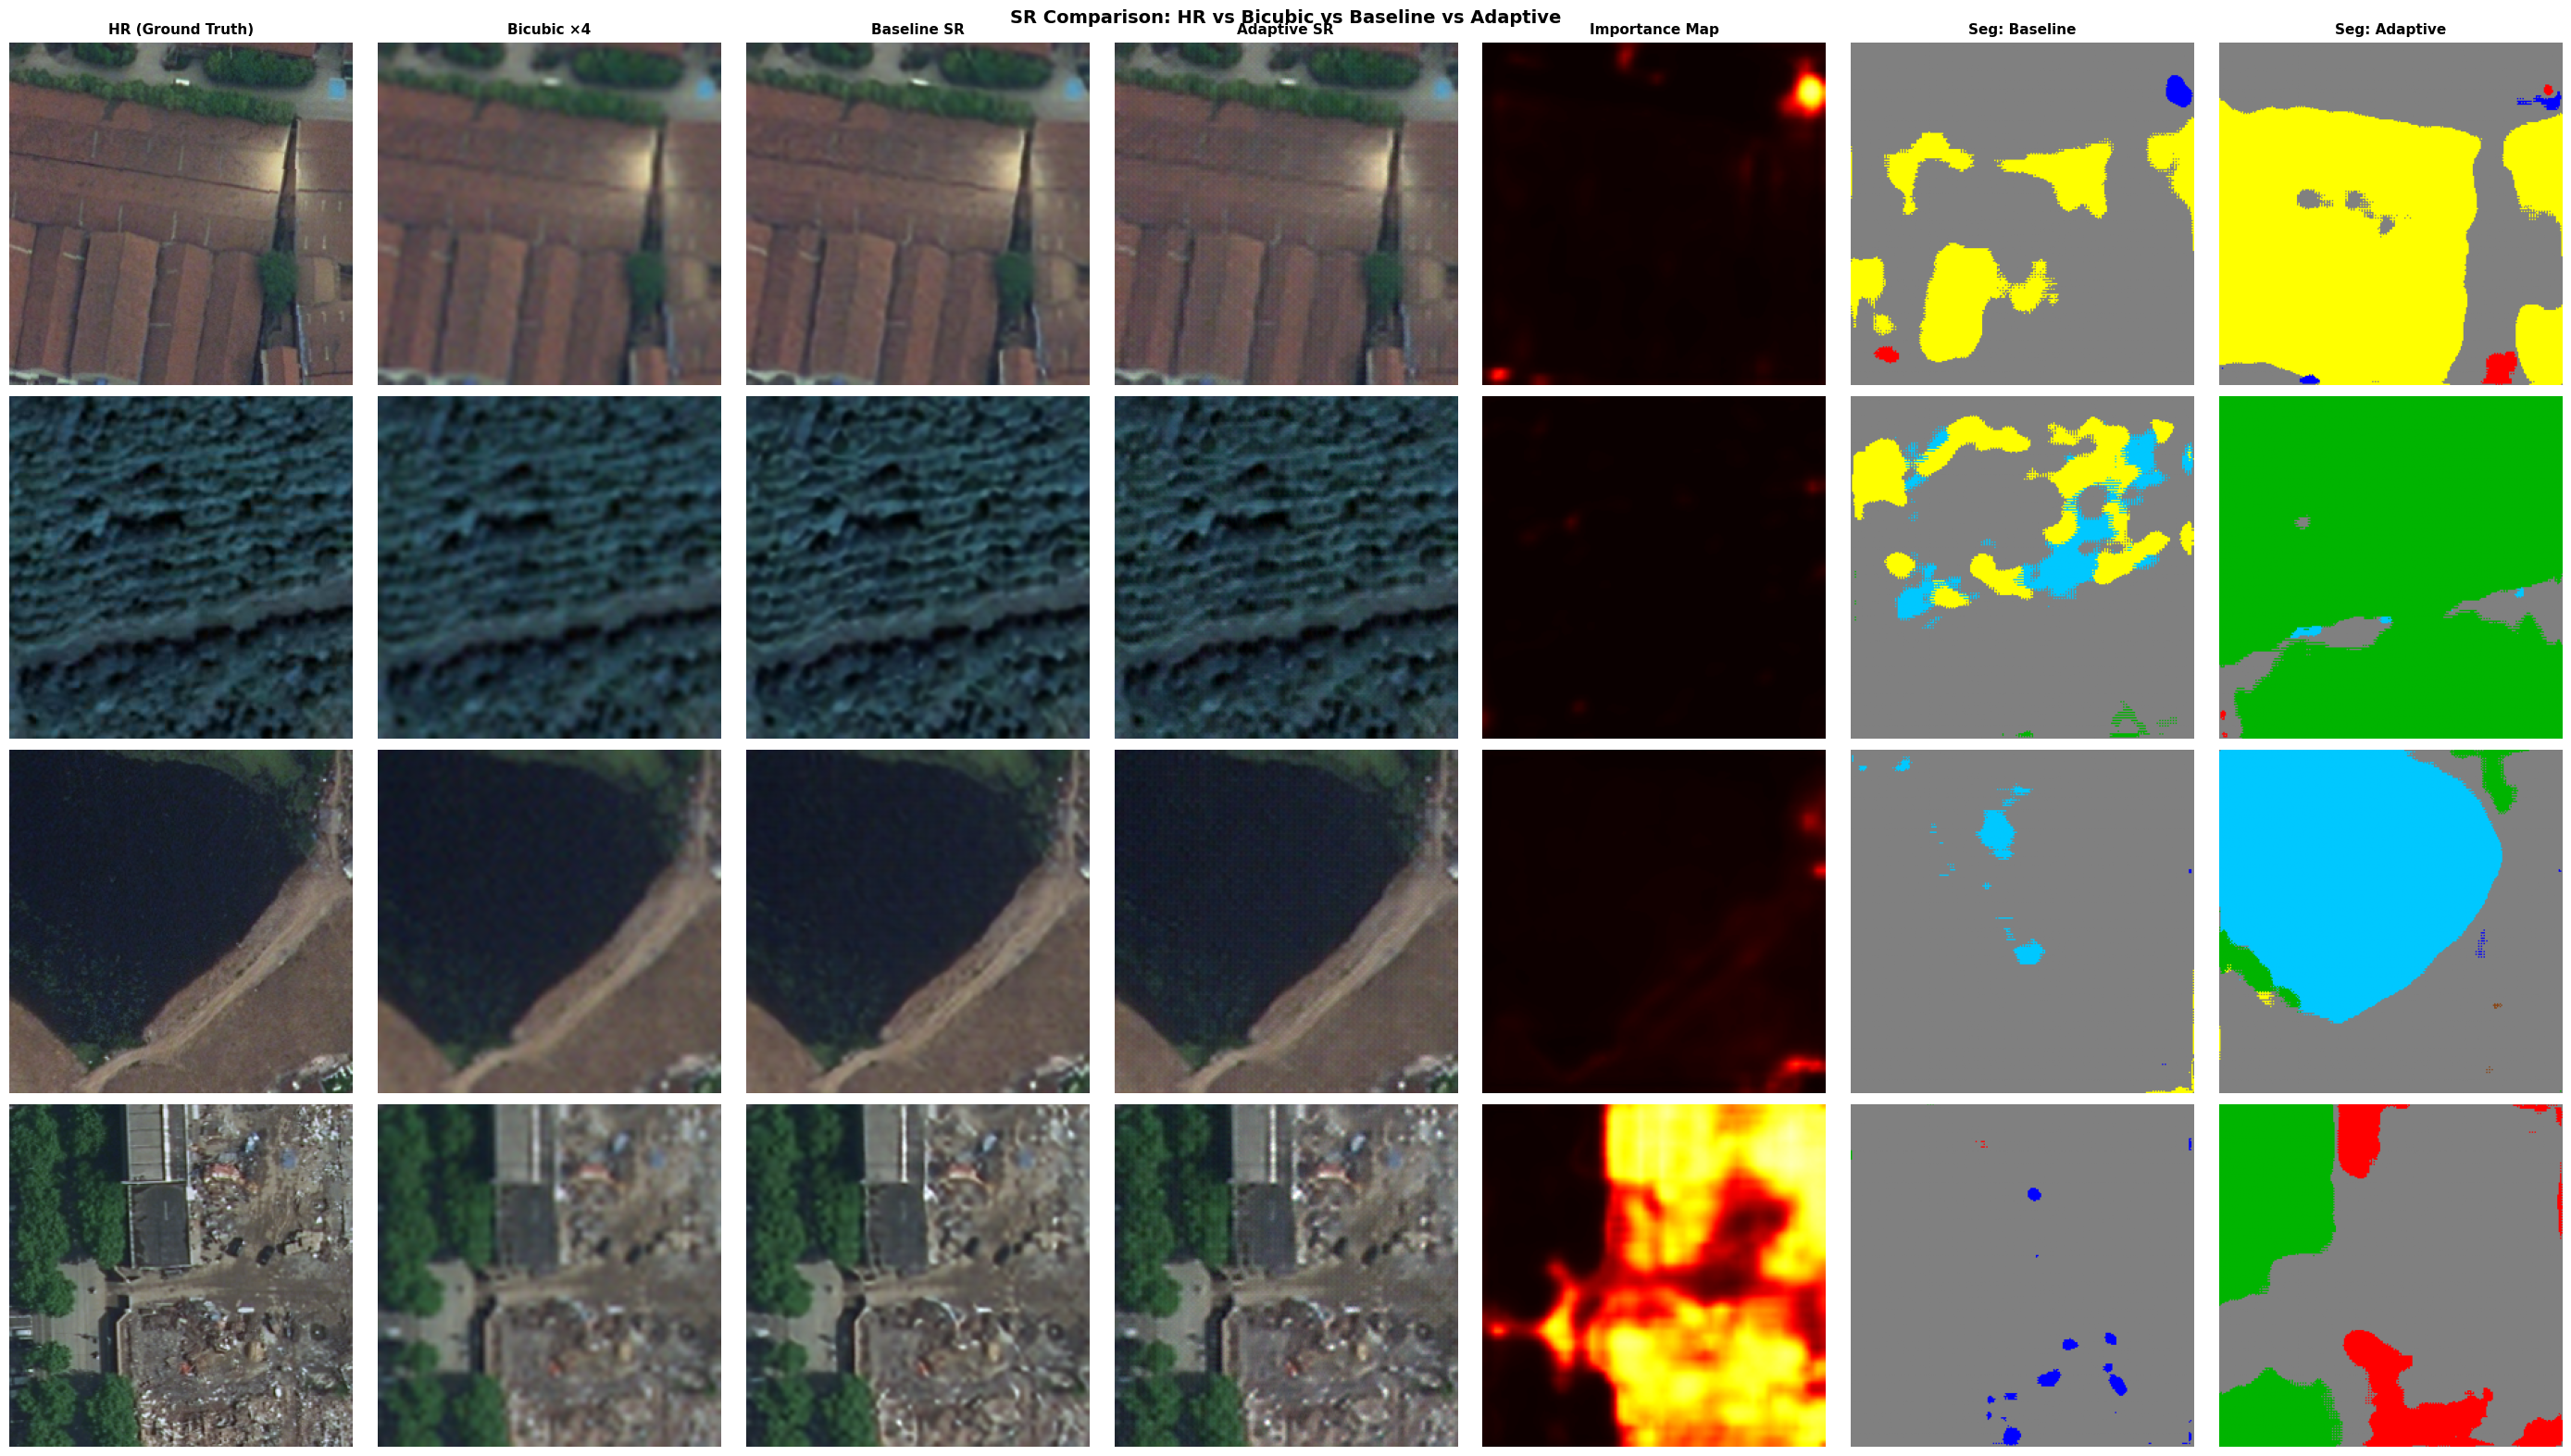

Saved comparison_grid.png


In [18]:
# ==================== COMPARISON GRID ====================
sample_batch = next(iter(DataLoader(val_dataset, batch_size=4, shuffle=True)))
lr_img = sample_batch['lr'].to(device)
hr_img = sample_batch['hr'].to(device)
mask = sample_batch['mask'].to(device)

with torch.no_grad(), autocast('cuda', enabled=USE_AMP):
    bicubic = F.interpolate(lr_img, scale_factor=SCALE, mode='bicubic',
                             align_corners=False).clamp(0, 1)
    importance = rin(lr_img)
    baseline_sr = baseline_gen(lr_img)
    adaptive_sr = adaptive_gen(lr_img, importance)
    seg_baseline = colorize_mask(seg_model(baseline_sr.float()).argmax(1).cpu().numpy())
    seg_adaptive = colorize_mask(seg_model(adaptive_sr.float()).argmax(1).cpu().numpy())

# Move to CPU for plotting
bicubic, baseline_sr, adaptive_sr = bicubic.float().cpu(), baseline_sr.float().cpu(), adaptive_sr.float().cpu()
importance = importance.float().cpu()
hr_img = hr_img.cpu()
del lr_img, mask
torch.cuda.empty_cache()

fig, axes = plt.subplots(4, 7, figsize=(28, 16))
titles = ['HR (Ground Truth)', 'Bicubic \u00d74', 'Baseline SR', 'Adaptive SR',
          'Importance Map', 'Seg: Baseline', 'Seg: Adaptive']

for row in range(4):
    imgs = [
        hr_img[row].permute(1,2,0).numpy(),
        bicubic[row].permute(1,2,0).numpy(),
        baseline_sr[row].permute(1,2,0).numpy(),
        adaptive_sr[row].permute(1,2,0).numpy(),
        importance[row, 0].numpy(),
        seg_baseline[row],
        seg_adaptive[row]
    ]
    for col, (img, t) in enumerate(zip(imgs, titles)):
        axes[row, col].imshow(img, cmap='hot' if col == 4 else None,
                               vmin=0 if col == 4 else None,
                               vmax=1 if col == 4 else None)
        if row == 0:
            axes[row, col].set_title(t, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')

plt.suptitle('SR Comparison: HR vs Bicubic vs Baseline vs Adaptive',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved comparison_grid.png")

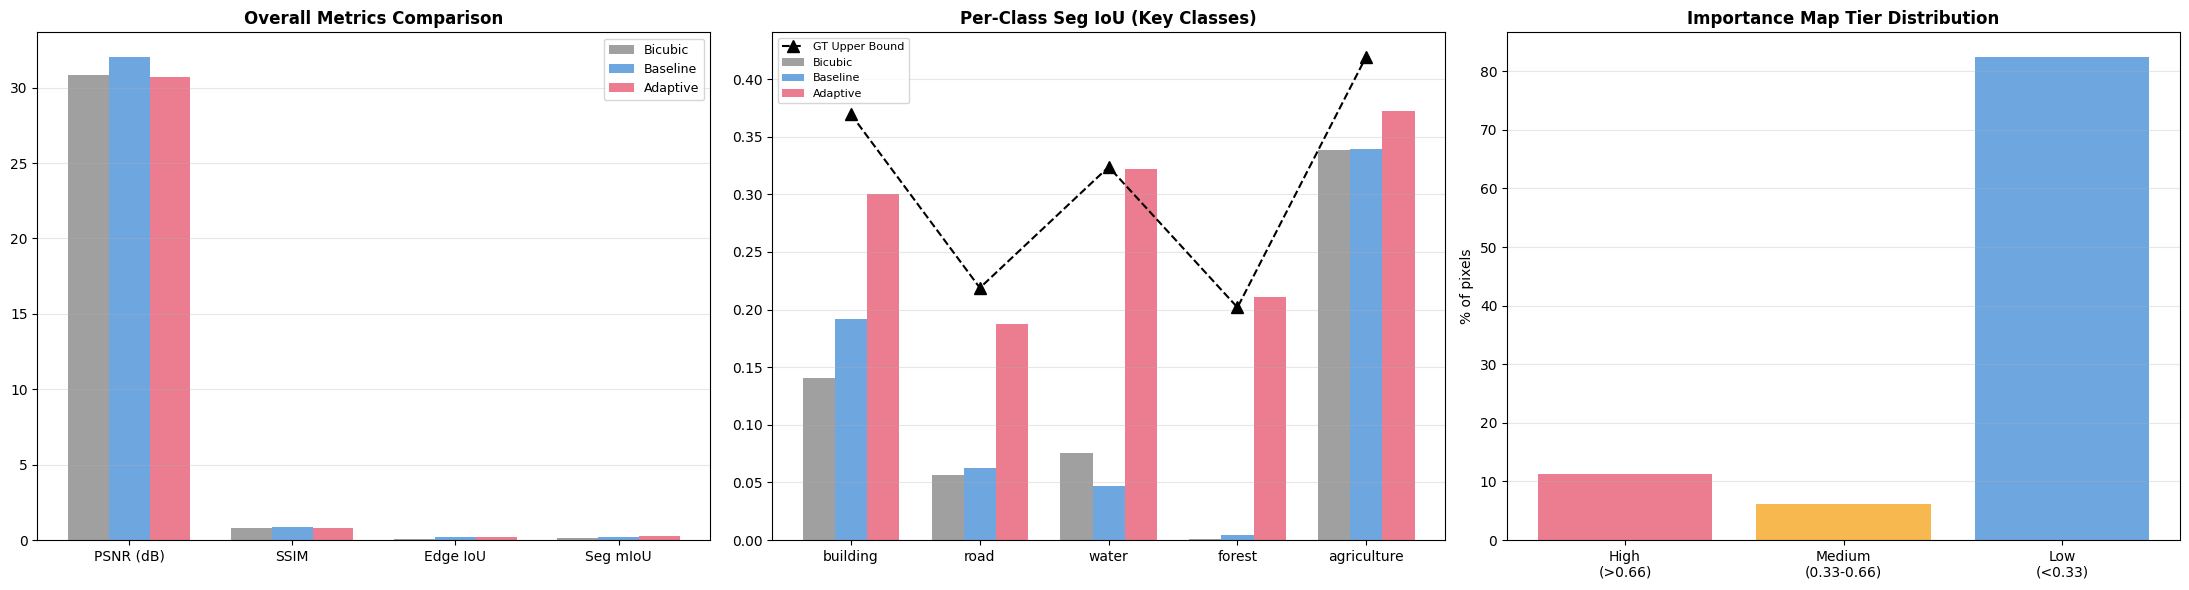

Saved metrics_analysis.png


In [19]:
# ==================== BAR CHARTS & IMPORTANCE ANALYSIS ====================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Overall metrics comparison
metric_names = ['PSNR (dB)', 'SSIM', 'Edge IoU', 'Seg mIoU']
baseline_vals = [np.mean(results['baseline'][k]) for k in ['psnr', 'ssim', 'edge_iou', 'miou']]
adaptive_vals = [np.mean(results['adaptive'][k]) for k in ['psnr', 'ssim', 'edge_iou', 'miou']]
bicubic_vals = [np.mean(results['bicubic'][k]) for k in ['psnr', 'ssim', 'edge_iou', 'miou']]

x = np.arange(len(metric_names))
width = 0.25
axes[0].bar(x - width, bicubic_vals, width, label='Bicubic', color='#888888', alpha=0.8)
axes[0].bar(x, baseline_vals, width, label='Baseline', color='#4A90D9', alpha=0.8)
axes[0].bar(x + width, adaptive_vals, width, label='Adaptive', color='#E85D75', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, fontsize=10)
axes[0].set_title('Overall Metrics Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 2. Per-class segmentation mIoU (key classes)
key_classes = ['building', 'road', 'water', 'forest', 'agriculture']
x2 = np.arange(len(key_classes))
for i, name in enumerate(['bicubic', 'baseline', 'adaptive']):
    vals = [np.mean(per_class_results[name][c]) if per_class_results[name][c] else 0
            for c in key_classes]
    color = ['#888888', '#4A90D9', '#E85D75'][i]
    label = ['Bicubic', 'Baseline', 'Adaptive'][i]
    axes[1].bar(x2 + i * width - width, vals, width, label=label, color=color, alpha=0.8)
# Add GT upper bound
gt_vals = [np.mean(per_class_results['gt'][c]) if per_class_results['gt'][c] else 0
           for c in key_classes]
axes[1].plot(x2, gt_vals, 'k^--', markersize=8, label='GT Upper Bound', linewidth=1.5)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(key_classes, fontsize=10)
axes[1].set_title('Per-Class Seg IoU (Key Classes)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# 3. Importance map distribution
axes[2].bar(['High\n(>0.66)', 'Medium\n(0.33-0.66)', 'Low\n(<0.33)'],
            [np.mean(tier_high)*100, np.mean(tier_med)*100, np.mean(tier_low)*100],
            color=['#E85D75', '#F5A623', '#4A90D9'], alpha=0.8)
axes[2].set_ylabel('% of pixels')
axes[2].set_title('Importance Map Tier Distribution', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/metrics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved metrics_analysis.png")

## 8. Ablation Study & Results Summary

Demonstrate the contribution of each component:
- **Bicubic**: No learning (baseline lower bound)
- **Baseline SR**: Learned SR with attention but no adaptive routing or task guidance
- **Adaptive SR**: Full model with importance-guided routing + task-guided + perceptual losses

The key story: *Adaptive SR trades marginal PSNR for significantly better downstream segmentation quality, especially on buildings and roads.*

In [20]:
# ==================== ABLATION SUMMARY TABLE ====================
print("="*90)
print("ABLATION SUMMARY")
print("="*90)
print(f"{'Variant':<25} {'PSNR':>8} {'SSIM':>8} {'Edge IoU':>10} {'Seg mIoU':>10} {'Build IoU':>10} {'Road IoU':>10}")
print("-"*90)

for name, label in [('bicubic', 'Bicubic (no learning)'),
                     ('baseline', 'Baseline SR'),
                     ('adaptive', 'Adaptive SR (full)')]:
    r = results[name]
    build_iou = np.mean(per_class_results[name]['building']) if per_class_results[name]['building'] else 0
    road_iou = np.mean(per_class_results[name]['road']) if per_class_results[name]['road'] else 0
    print(f"{label:<25} {np.mean(r['psnr']):>8.2f} {np.mean(r['ssim']):>8.4f} "
          f"{np.mean(r['edge_iou']):>10.4f} {np.mean(r['miou']):>10.4f} "
          f"{build_iou:>10.4f} {road_iou:>10.4f}")

build_gt = np.mean(per_class_results['gt']['building']) if per_class_results['gt']['building'] else 0
road_gt = np.mean(per_class_results['gt']['road']) if per_class_results['gt']['road'] else 0
print(f"{'GT Upper Bound':<25} {'--':>8} {'--':>8} {'--':>10} {np.mean(gt_miou):>10.4f} "
      f"{build_gt:>10.4f} {road_gt:>10.4f}")
print("="*90)

print(f"\nFLOPs: Baseline {baseline_flops/1e9:.3f}G | Adaptive (soft) {adaptive_flops_soft/1e9:.3f}G | "
      f"Adaptive (hard, projected) {effective_flops/1e9:.3f}G")
print(f"Timing: Baseline {baseline_time:.2f} ms/img | Adaptive {adaptive_time:.2f} ms/img")
print(f"High-importance regions: {np.mean(tier_high)*100:.1f}% of pixels")

ABLATION SUMMARY
Variant                       PSNR     SSIM   Edge IoU   Seg mIoU  Build IoU   Road IoU
------------------------------------------------------------------------------------------
Bicubic (no learning)        30.81   0.8103     0.0862     0.1700     0.1405     0.0566
Baseline SR                  32.06   0.8458     0.1920     0.1736     0.1921     0.0624
Adaptive SR (full)           30.70   0.7928     0.1728     0.2828     0.3005     0.1878
GT Upper Bound                  --       --         --     0.3096     0.3692     0.2188

FLOPs: Baseline 6.789G | Adaptive (soft) 12.426G | Adaptive (hard, projected) 7.426G
Timing: Baseline 11.94 ms/img | Adaptive 65.49 ms/img
High-importance regions: 11.3% of pixels


In [21]:
# ==================== SAVE ALL RESULTS ====================

# JSON results
all_results = {
    'overall_metrics': {
        name: {k: float(np.mean(v)) for k, v in results[name].items()}
        for name in results
    },
    'per_class_iou': {
        name: {k: float(np.mean(v)) if v else None for k, v in per_class_results[name].items()}
        for name in per_class_results
    },
    'gt_upper_bound_miou': float(np.mean(gt_miou)),
    'flops': {
        'baseline_gflops': float(baseline_flops / 1e9),
        'adaptive_soft_gflops': float(adaptive_flops_soft / 1e9),
        'adaptive_hard_projected_gflops': float(effective_flops / 1e9),
        'high_importance_pct': float(np.mean(tier_high)),
    },
    'timing_ms_per_image': {
        'baseline': float(baseline_time),
        'adaptive': float(adaptive_time),
    },
    'tier_distribution': {
        'high_pct': float(np.mean(tier_high)),
        'med_pct': float(np.mean(tier_med)),
        'low_pct': float(np.mean(tier_low)),
    }
}

with open('/kaggle/working/eval_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("Saved eval_results.json")

# CSV per-class metrics
import csv
with open('/kaggle/working/per_class_metrics.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Class'] + list(per_class_results.keys()))
    for cls in CLASS_NAMES[1:]:
        row = [cls]
        for method in per_class_results:
            vals = per_class_results[method][cls]
            row.append(f"{np.mean(vals):.4f}" if vals else "N/A")
        writer.writerow(row)
print("Saved per_class_metrics.csv")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)
print("Outputs saved to /kaggle/working/:")
print("  - eval_results.json")
print("  - per_class_metrics.csv")
print("  - comparison_grid.png")
print("  - metrics_analysis.png")
print("  - checkpoints/ (all model checkpoints)")

Saved eval_results.json
Saved per_class_metrics.csv

ALL DONE!
Outputs saved to /kaggle/working/:
  - eval_results.json
  - per_class_metrics.csv
  - comparison_grid.png
  - metrics_analysis.png
  - checkpoints/ (all model checkpoints)
